In [1]:
# 6-22 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F

import os
import cv2
import random
from PIL import Image
#from tqdm import tqdm_notebook as tqdm
from tqdm.notebook import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
# 6-23 데이터 전처리
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train' : transforms.Compose([ #Compose : 여러 전처리를 순서대로 묶어서 한 번에 실행되게 만드는 도구
                # 모델이 데이터를 외우지 않도록 조금씩 조정하여 데이터 증강 
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)), #무작위로 잘라서 크기 맞춤
                transforms.RandomHorizontalFlip(), # 좌우 무작위 뒤집기
                transforms.ToTensor(), #텐서로 변환
                transforms.Normalize(mean, std) #정규화
            ]),
            'val' : transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }
    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [3]:
# 6-24 데이터를 가져와 훈련, 검증, 테스트 용도로 분리
cat_directory = './data/dogs-vs-cats/Cat/'
dog_directory = './data/dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)]) #파일명과 경로명 병합
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)]) #파일명과 경로명 병합

images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None] #없을 때까지 반복하여 이미지 넣음 

random.seed(42) #난수 값(42엔 고정)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]

print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

#AlexNet은 파라미터를 600만개 사용하는 모델 (이때 충분한 데이터가 없으면 과적합이 발생하는 등 테스트 데이터 성능이 좋지 않음) 
# -> 따라서 예제의 경우 데이터에 대한 성능이 안좋을 수 밖에 없음

400 92 10


In [4]:
# 6-25 커스텀 데이터셋 정의
class DogvsCatDatset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list #이미지 데이터가 위치한 파일 경로
        self.transform = transform #이미지 데이터 전처리
        self.phase = phase #self.phase : ImageTransform()에서 정의한 'train'과 'val'을 의미

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx] #이미지 데이터의 인덱스 가져오기
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0] #lable(정답지) 가져오기

        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0

        return img_transformed, label #전처리가 적용된 이미지와 레이블(정답지) 반환

In [5]:
# 6-26 변수에 대한 값 정의
size = 256 #AlexNet : 깊이가 깊은 네트워크를 사용, 이미지 크기가 256이 아니면 풀링층 때문에 크기가 계속 줄어들어 오류가 발생할 수 있음

mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [6]:
# 6-27 훈련, 검증, 데이터셋 정의
train_dataset = DogvsCatDatset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDatset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
test_dataset = DogvsCatDatset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
0


In [7]:
# 6-28 데이터셋을 메모리로 불러옴
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

dataloader_dict = {'train' : train_dataloader, 'val' : val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)

print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 0])


In [8]:
# 6-29 AlexNet 모델 네트워크 정의
class AlexNet(nn.Module):
    def __init__(self) -> None: #return으로 값을 돌려주지 않기 때문에 None
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True), #1
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((6, 6)) #2

        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256*6*6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 2)
        )


    def forward(self, x : torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) #한줄로 폄 (nn.Linear은 한줄을 받음)
        x = self.classifier(x)
        return x

# 1. ReLU() 활성화 함수의 inplace : 연산에 대한 결괏 값을 새로운 변수에 저장하는 것이 아닌 기존 데이터를 대체히는 것을 의미 
# -> 기존 값을 연산 결괏값으로 대체함으로써 기존 값을 무시

# 2. nn.AdaptiveAvgPool2d -> nn.AvgPool2d 처럼 풀링을 위해 사용
# AdaptiveAvgPool2d(x, y) -> (x, y)로 고정해서 나옴
# AvgPool2d((3, 2), stride=(2,1) -> 계산해서 나옴, (7, 7) --pooling--> ((7-3)/ 2)+1 = 3, (7-2)/1 + 1 = 6

In [9]:
import torch
import torch.nn as nn

pool = nn.AvgPool2d((3, 2), stride=(2, 1))
print(pool(torch.randn(1, 1, 7, 7)).shape)   # torch.Size([1, 1, 3, 6])
print(pool(torch.randn(1, 1, 5, 5)).shape)   # torch.Size([1, 1, 2, 4])

torch.Size([1, 1, 3, 6])
torch.Size([1, 1, 2, 4])


In [10]:
# 6-30 model 객체 생성
model = AlexNet()
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [11]:
# 6-31 옵티마이저 및 손실 함수 정의
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

In [12]:
# 6-32 모델 네트워크 구조 확인
from torchsummary import summary

summary(model, input_size=(3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

In [13]:
# 6-33 모델 학습 함수 정의
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch): #epoch를 10으로 설정했으므로 10회 반복
        print('Epoch {}/{}'.format(epoch+1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() #모델 학습
            else:
                model.eval() #평가(시험) 모드로 전환

        epoch_loss = 0.0
        epoch_corrects = 0

        for inputs, labels in tqdm(dataloader_dict[phase]): #여기서 dataloader_dict는 훈련 데이터셋(train_loader) 의미
            inputs = inputs.to(device) #훈련 데이터셋을 CPU에 할당
            labels = labels.to(device) 
            optimizer.zero_grad() #역전파 단계를 실행하기 전에 기울기(gradient)를 0으로 초기화

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels) #손실 함수를 이용한 오차 계산

                if phase == 'train' :
                    loss.backward() #모델의 학습 가능한 모든 파라미터에 대해 기울기 계산(역전파)
                    optimizer.step() #optimizer의 step()을 호출하면 파라미터 갱신

                epoch_loss += loss.item() * inputs.size(0) #1
                epoch_corrects += torch.sum(preds == labels.data) #정답과 예측이 일치하면 그것의 함계를 epoch_corrects에 저장

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset) # 최종 오차 계산 (오차를 데이터셋의 길이(개수)로 나누어 계산)
            epoch_acc = epoch_corrects / len(dataloader_dict[phase].dataset) #최종 정확도 계산 (epoch_corrects를 데이터셋 길이(개수)로 나누어 계산)

            print('{} Loss: {:.4f} Acc : {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc: #검증 데이터셋에 대한 가장 최적의 정확도를 저장
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val Acc: {:4f}'.format(best_acc))
    return model

In [14]:
# 6-34 모델 학습
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2413 Acc : 0.1630
val Loss: 0.2436 Acc : 0.3478
val Loss: 0.2138 Acc : 0.4891
Epoch 2/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2413 Acc : 0.1630
val Loss: 0.2436 Acc : 0.3478
val Loss: 0.2138 Acc : 0.4891
Epoch 3/10
--------------------


...

val Loss: 0.2413 Acc : 0.1630
val Loss: 0.2436 Acc : 0.3478
val Loss: 0.2138 Acc : 0.4891
Epoch 9/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2413 Acc : 0.1630
val Loss: 0.2436 Acc : 0.3478
val Loss: 0.2138 Acc : 0.4891
Epoch 10/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2413 Acc : 0.1630
val Loss: 0.2436 Acc : 0.3478
val Loss: 0.2138 Acc : 0.4891
training complete in 0m 7s
Best val Acc: 0.489130


In [17]:
# 6-35 모델을 이용한 예측
import pandas as pd

id_list = []
pred_list = []

_id = 0

with torch.no_grad():
    for test_path in tqdm(test_images_filepaths): #테스트 이미지 데이터 이용
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1] #이미지 데이터의 번호 가져오기

        transform = ImageTransform(size, mean, std)

        img = transform(img, phase='val') #테스트 데이터에 검증용 전처리 적용
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()

        id_list.append(_id)
        pred_list.append(preds[0])
        
res = pd.DataFrame({
    'id' : id_list,
    'label' : pred_list
}) #데이터 프레임에 이미지 id(번호)와 레이블 저장

res.to_csv('./data/elexnet.csv', index=False) #이미지의 id와 label을 alexnet.csv 파일에 저장

  0%|          | 0/10 [00:00<?, ?it/s]

In [18]:
# 6-36 데이터 프레암 결과 확인
res.head(10)

,id,label
0,145,0.496986
1,211,0.496821
2,162,0.497091
3,200,0.495975
4,210,0.496661
5,224,0.497279
6,213,0.497214
7,109,0.496499
8,15,0.497065
9,167,0.497381


In [24]:
# 6-37 예측 결과를 시각적으로 표현하기 위한 함수 정의
from matplotlib import pyplot as plt

class_ = classes = {0:'cat', 1:'dog'}

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))

    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]

        if label > 0.5:
            label = 1
        else:
            label = 0

        #ravel() : 여러 차원의 배열을 1차원 한 줄로 쭉 펴는 numpy 함수
        # 격자 이미지를 한줄로 뽑애내기 위해 한줄로 쭉 핌
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
        
    plt.tight_layout() #칸 사이 간격을 자동으로 정리해서 글자나 그림이 겹치지 않게해주는 함수
    plt.show()

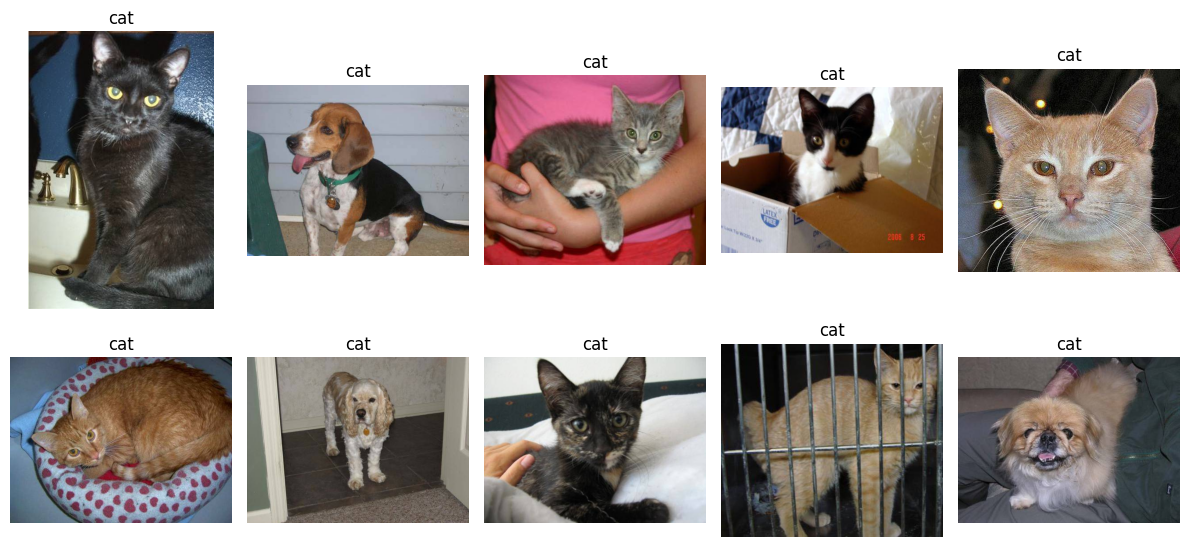

In [25]:
# 6-38 예측 결과에 대해 이미지와 함께 출력
display_image_grid(test_images_filepaths)

#-> 한정된 자원에서 성능이 안좋을 수 밖에 없지만 성능의 경우 파라미터 튜닝을 통해 향상시킬 수도 있음